In [15]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from scipy.optimize import root

s = Simulation()
N_t = 500
tg = 250 * 4
tlist = np.linspace(0, tg, N_t)
sigma = 0.3

# compute cos params
cos_amp, cos_wd = compute_cos_params(s, tg)
heff_params = s.heff(cos_wd, cos_amp)
Delta = heff_params[2][2] - heff_params[0][0]
# rrr follows from the heff response to amplitude, as both Omega_ab and Omega_bc are linear rrr is constant for all amp- and wd values
rrr = heff_params[1][2] / heff_params[0][1] # compute the RabiRateRatio (RRR) from the two rabirates in cos dirve case
rrr, Delta

(np.complex128(10.018939148808327+0j), np.complex128(-1.1736026791361351+0j))

In [2]:
# with a given gate time we compute the fidelity for cos drive and drag drive
def compute_htarget(tg, use_drag=True):
    ht, ht_args = h_target(Delta, rrr, tg, use_drag = use_drag, sigma_r = sigma)
    return ht, ht_args
ht, args = compute_htarget(tg)

/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


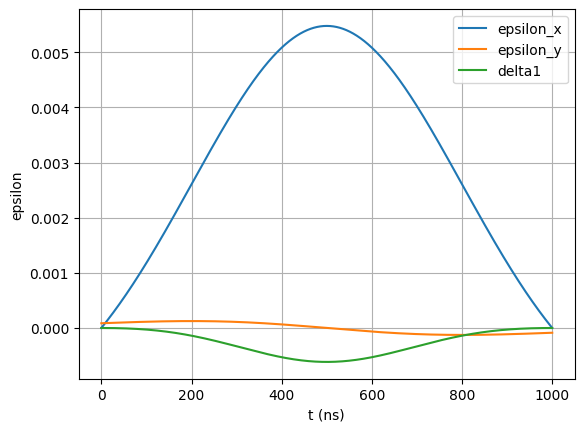

In [3]:
ex = np.array([args[0](t) for t in tlist])
ey = np.array([args[1](t)*10 for t in tlist])
d1 = np.array([args[2](t) for t in tlist])
plt.figure()
plt.plot(tlist, ex, label='epsilon_x')
plt.plot(tlist, ey, label='epsilon_y')
plt.plot(tlist, d1, label='delta1')
plt.xlabel('t (ns)')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()

To check gate fidelity with target hamiltonian, we sweep tg and compute Delta and rrr accordingly


Also we use a normal effective hamiltonian for cos drive to compensate compare

100%|██████████| 20/20 [00:02<00:00,  8.59it/s]


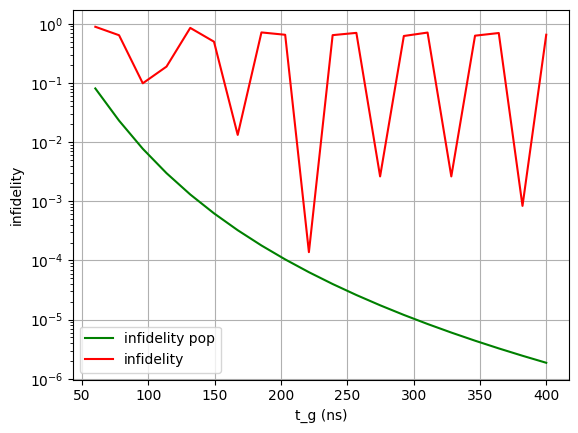

In [4]:
def plot_tg_fid_curve(hamiltonian_function, n, tg_min = 60, tg_max = 400):
    lf_pop = []
    lf = []
    ltg = np.linspace(tg_min, tg_max, n)
    for tg in tqdm(ltg):
        h, _ = hamiltonian_function(tg)
        tlist = np.linspace(0, tg, N_t)
        f = extract_fidelity(h, tlist)
        fpop = extract_pop_fid(h, tlist)['iswap_fidelity']
        lf_pop.append(1-fpop)
        lf.append(1-f)
    ax = plt.subplot()
    plt.plot(ltg, lf_pop, label='infidelity pop', color='green')
    plt.plot(ltg, lf, label='infidelity', color='red')
    plt.xlabel('t_g (ns)')
    plt.ylabel('infidelity')
    ax.set_yscale('log')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_tg_fid_curve(compute_htarget, 20)

After verifying the fidelity of the target-hamiltonian, now the target hamiltonian must be achieved by a given time-dependant pulse-shape that is applied to the coupler

In [5]:
import pickle
from pathlib import Path
ROOT = Path.cwd()
# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
coeff_dir.mkdir(parents=True, exist_ok=True)
coeff_file = coeff_dir / 'heff_coefficients.pkl'
wd_range = [0.7 * 2*np.pi, 0.712 * 2*np.pi] # TODO anpassen
amp_real_max = 1.0 * 2 * np.pi
amp_imag_max = amp_real_max / 8
amp_real_range = (-amp_real_max, amp_real_max)
amp_imag_range = (-amp_imag_max, amp_imag_max)

# Load coefficients
with open(coeff_file, 'rb') as f:
    coefficients_data = pickle.load(f)
coeffs01 = coefficients_data['coeffs01']
coeffs00 = coefficients_data['coeffs00']
coeffs11 = coefficients_data['coeffs11']
# coeffs12 = coefficients_data['coeffs12']
coeffs22 = coefficients_data['coeffs22']
# coeffs02 = coefficients_data['coeffs02']
print(f"Coefficients loaded from {coeff_file}")

def heff_fit(coeffs, wd, amp):
    ar, ai = np.real(amp), np.imag(amp)
    x = [1, wd, ar, ai, wd**2, ar**2, ai**2,
                wd*ar, wd*ai, ar*ai]
    if not len(coeffs) == 10:
        x.extend([
            wd**3, ar**3, ai**3,
            wd**2*ar, wd**2*ai,
            wd*ar**2, wd*ai**2,
            ar**2*ai, ar*ai**2,
            wd*ar*ai])
    return np.array(x) @ coeffs

Coefficients loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_coefficients.pkl


setup the functions that are used to optimize the 3 independent parameters wd, amp_r and amp_i for achieving max compliance with the target hamiltonian. 

In [ ]:
from scipy.optimize import least_squares

def find_parameter_change_fit(wd0, heff_t, prev_solution):
    if not prev_solution:
        prev_solution = [0,0,0]
    def residuals(x):
        dw, ar, ai = x
        wd = wd0 + dw
        amp = ar + 1j*ai 

        deltadiff = (heff_fit(coeffs00, wd, amp) - heff_fit(coeffs11, wd, amp)) - (heff_t[0,0] - heff_t[1,1])
        # deltadiff2 = (heff_fit(coeffs11, wd, amp) - heff_fit(coeffs22, wd, amp)) - (heff_t[1,1] - heff_t[2,2])
        omega_diff = heff_fit(coeffs01, wd, amp) - heff_t[0,1]

        weights = np.array([1,
                            1,
                            1,])
        return weights*np.array([
            abs(deltadiff),
            np.real(omega_diff),
            np.imag(omega_diff)])
    dwd_range = (-1,1)
    res = least_squares(residuals, x0=[prev_solution[0], prev_solution[1], prev_solution[2]], 
                        bounds=([wd_range[0] - wd0, amp_real_range[0], amp_imag_range[0]], 
                                [wd_range[1] - wd0, amp_real_range[1], amp_imag_range[1]]))
    return {"dw": res.x[0], "dar": res.x[1], "dai": res.x[2]}

from scipy.optimize import minimize
def find_parameters_error(wd0, heff_t, prev_solution):
    lambda_leak = 1
    def objective(x):
        dw, ar, ai = x
        wd = wd0 + dw
        amp = ar + 1j*ai

        deltadiff = (
            heff_fit(coeffs00, wd, amp)
            - heff_fit(coeffs11, wd, amp)
        ) - (heff_t[0,0] - heff_t[1,1])

        deltadiff2 = (
            heff_fit(coeffs11, wd, amp)
            - heff_fit(coeffs22, wd, amp)
        ) - (heff_t[1,1] - heff_t[2,2])

        omega_diff = heff_fit(coeffs01, wd, amp) - heff_t[0,1]
        omega2_diff = heff_fit(coeffs12, wd, amp) - heff_t[1,2]
        omega3_diff = heff_fit(coeffs02, wd, amp) - heff_t[0,2]

        return (
            abs(deltadiff) * 2
            + abs(omega_diff)
            + abs(omega2_diff)
            + abs(omega3_diff)
            - lambda_leak * np.real(deltadiff2)
        )
    res = minimize(
        objective,
        x0=[0, 0, 0],
        bounds=[(-1,1),amp_real_range,amp_imag_range],method="L-BFGS-B")
    result = {"dw": res.x[0],"dar": res.x[1],"dai": res.x[2]}
    return result

# define a function to change the list representation of h_target to one time dependant matrix function
def sum_list(ht):
    def f(t):
        result = ht[0]
        for i in range(1, len(ht)):
            result = result + ht[i][0] * ht[i][1](t)
        return result
    return f

setup the heff_modulated method and test hamiltonian compliance with one example

In [7]:
ht, _ = compute_htarget(tg)
ht_func = sum_list(ht)
wd0 = s.find_resonance(0)
def heff_modulated(t, args=None):
    res = find_parameter_change_fit(wd0, ht_func(t), None)
    dw = res['dw']
    da = res['dar'] + 1j*res['dai']
    return Qobj(s.heff(wd0 + dw.real, da))
    
# for some examples, show if the hamiltonian comes close to the target
tt = 200
print("h0: ")
print("heff_modulated: ")
h_mod = heff_modulated(tt)
# for i in range(0,2):
#     h_mod[i][i] -= h_mod[0][0]
display(h_mod)
print("htarget: ")
display(ht_func(tt))

h0: 
heff_modulated: 


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.22768253e-05+0.00000000e+00j  1.30312540e-03-6.88490224e-06j
  -8.34987989e-05+8.82335831e-07j]
 [ 1.30312540e-03+6.88490224e-06j -1.51570663e-04+0.00000000e+00j
   1.30565878e-02-6.89828705e-05j]
 [-8.34987989e-05-8.82335831e-07j  1.30565878e-02+6.89828705e-05j
  -1.17392282e+00+0.00000000e+00j]]

htarget: 


Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.00000000e+00+0.00000000e+00j  1.30255129e-03-6.27775991e-06j
   0.00000000e+00+0.00000000e+00j]
 [ 1.30255129e-03+6.27775991e-06j -1.39299002e-04+0.00000000e+00j
   1.30501821e-02-6.28964945e-05j]
 [ 0.00000000e+00+0.00000000e+00j  1.30501821e-02+6.28964945e-05j
  -1.17360268e+00+0.00000000e+00j]]

drive_signal_func gives the time dependant DRAG amplitude 

mesolve cannot deal with the difficult heff_modulated / pulse_shape_modulated functions as a parameter, so instead we precompute values and then simply interpolate between the defined values.

In [ ]:
force_computation = True
heff_file = coeff_dir / 'precomputed_heff_modulated.pkl'
drive_freq_precomputed = []
drive_amp_real_precomputed = []
drive_amp_imag_precomputed = []

if heff_file.exists() and not force_computation:
    with open(heff_file, 'rb') as f:
        heff_data = pickle.load(f)
    print(f"heff_modulated loaded from {heff_file}")
    drive_freq_precomputed = heff_data['frequency']
    drive_amp_real_precomputed = heff_data['amplitude_real']
    drive_amp_imag_precomputed = heff_data['amplitude_imag']
else:
    prev_sol = None
    for t in tqdm(tlist):
        res = find_parameter_change_fit(wd0, ht_func(t), prev_solution=prev_sol)
        freq= wd0 + res['dw']
        amp_real = res['dar']
        amp_imag = res['dai']
        drive_freq_precomputed.append(freq)
        drive_amp_real_precomputed.append(amp_real)
        drive_amp_imag_precomputed.append(amp_imag)
        prev_sol = [res['dw'], amp_real, amp_imag]
    
    drive_freq_precomputed = np.array(drive_freq_precomputed)
    drive_amp_real_precomputed = np.array(drive_amp_real_precomputed)
    drive_amp_imag_precomputed = np.array(drive_amp_imag_precomputed)
    heff_data = {
        'frequency': drive_freq_precomputed,
        'amplitude_real': drive_amp_real_precomputed,
        'amplitude_imag': drive_amp_imag_precomputed
    }
    with open(heff_file, 'wb') as f:
        pickle.dump(heff_data, f)
    print(f"frequency and amplitudes saved to {heff_file}")

100%|██████████| 2500/2500 [00:00<00:00, 2967.27it/s]

frequency and amplitudes saved to /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/precomputed_heff_modulated.pkl


In [9]:
def drive_wd_interp(t, args=None):
    if t <= tlist[0]:
        return drive_freq_precomputed[0]
    if t >= tlist[-1]:
        return drive_freq_precomputed[-1]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    return (1 - alpha) * drive_freq_precomputed[idx] + alpha * drive_freq_precomputed[idx + 1]

def drive_amp_interp(t, args=None):
    if t <= tlist[0]:
        return drive_amp_real_precomputed[0] + 1j*drive_amp_imag_precomputed[0]
    if t >= tlist[-1]:
        return 0
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    amp_real = (1 - alpha) * drive_amp_real_precomputed[idx] + alpha * drive_amp_real_precomputed[idx + 1]
    amp_imag = (1 - alpha) * drive_amp_imag_precomputed[idx] + alpha * drive_amp_imag_precomputed[idx + 1]
    return amp_real + 1j*amp_imag

def drive_signal_interp(t, args=None):
    return drive_amp_interp(t) * np.cos(drive_wd_interp(t) * t)

def heff_mod_build(t, args=None):
    wd = drive_wd_interp(t)
    a = drive_amp_interp(t)
    return Qobj(s.heff(wd, a))

min amp:  0.0  max:  0.2578191911690557


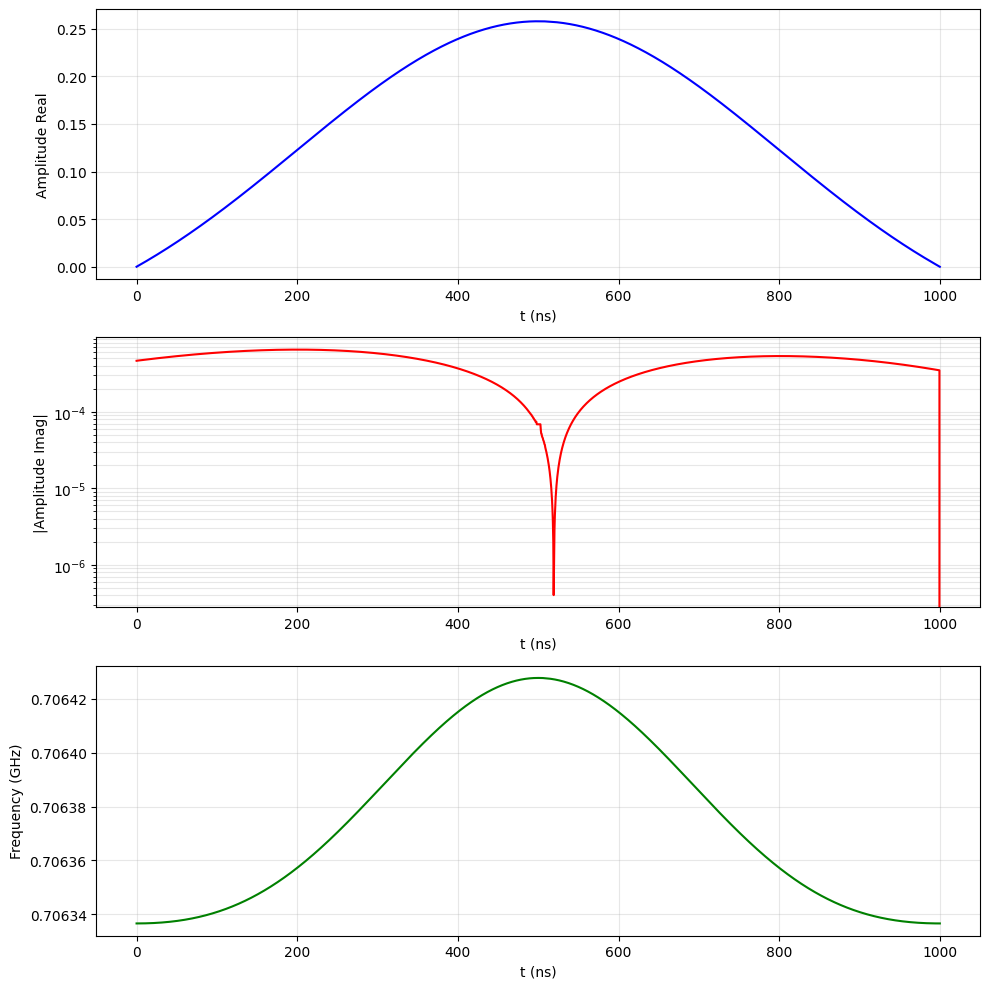

In [10]:
def plot_drive_components(t_end=tg, n=2000):
    t_vals = np.linspace(0, t_end, n)
    amp_real = np.array([drive_amp_interp(t).real for t in t_vals])
    # extremwerte:
    print("min amp: ", min(amp_real), " max: ", max(amp_real))
    amp_imag = np.array([drive_amp_interp(t).imag for t in t_vals])
    freq = np.array([drive_wd_interp(t) for t in t_vals])
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    
    axes[0].plot(t_vals, amp_real, 'b-', linewidth=1.5)
    axes[0].set_xlabel('t (ns)')
    axes[0].set_ylabel('Amplitude Real')
    axes[0].grid(True, which='both', alpha=0.3)
    
    axes[1].plot(t_vals, np.abs(amp_imag), 'r-', linewidth=1.5)
    axes[1].set_yscale('log')
    axes[1].set_xlabel('t (ns)')
    axes[1].set_ylabel('|Amplitude Imag|')
    axes[1].grid(True, which='both', alpha=0.3)
    
    axes[2].plot(t_vals, freq/(2*np.pi), 'g-', linewidth=1.5)
    axes[2].set_xlabel('t (ns)')
    axes[2].set_ylabel('Frequency (GHz)')
    axes[2].grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
plot_drive_components()

with the heff_modulated_interp function, the extraction of fidelity measurements can be done fast. To test for the right adoption of h_target, we compare fidelities for h_t, h_modulated and the raw hamiltonian with the given drive signal (h_drive). In the following those 3 cases will correspond to the values fid_engineered, fid_modulated, fid_drive.

In [11]:
# precompute heff_mod:
delta_t = 40
heff_mod_list = np.linspace(0, tlist[-1] + delta_t, len(tlist) + 20)
heff_precomputed = [heff_mod_build(t) for t in tqdm(heff_mod_list)]

def heff_modulated_interp(t):
    if t <= heff_mod_list[0]:
        return heff_precomputed[0]
    if t >= heff_mod_list[-1]:
        return heff_precomputed[-1]
    idx = np.searchsorted(heff_mod_list, t) - 1
    t0 = heff_mod_list[idx]
    t1 = heff_mod_list[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    return (1 - alpha) * heff_precomputed[idx] + alpha * heff_precomputed[idx + 1]

100%|██████████| 2520/2520 [03:06<00:00, 13.51it/s]


  0%|          | 0/24999 [00:00<?, ?it/s]

  0%|          | 0/24999 [00:00<?, ?it/s]

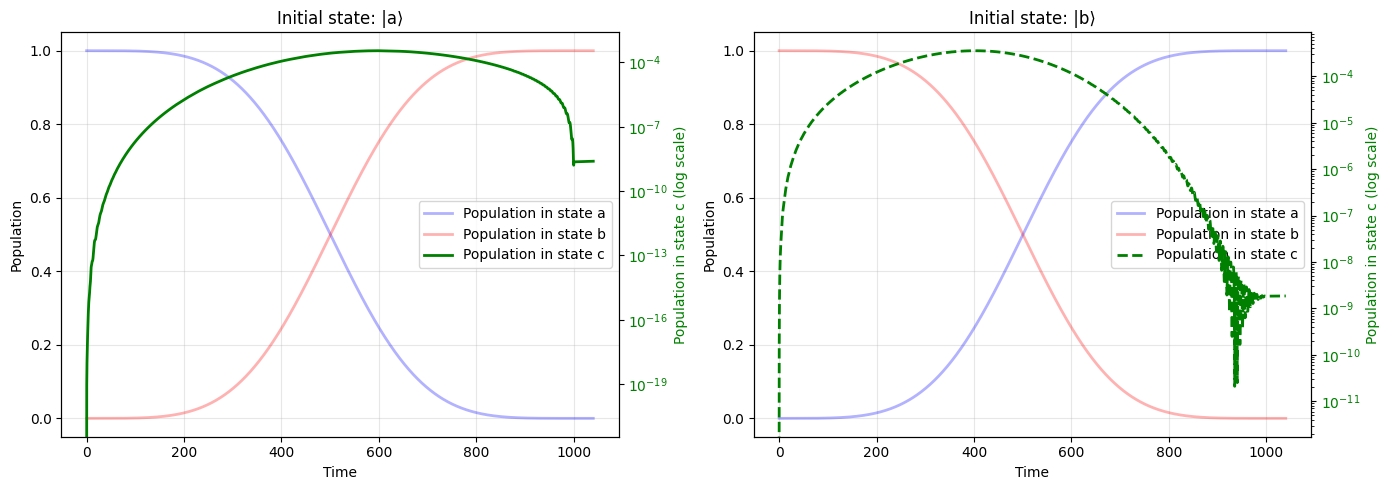

infidelity modulated pop: 6.38e-06


In [12]:
# modulated
tlist_fid = np.linspace(0, tg + delta_t, 25000)
# f_m = extract_fidelity(heff_modulated_interp, tlist_fid, debug=True ,plot=False)
fpop_m = extract_pop_fid(heff_modulated_interp, tlist_fid, debug=True,plot=True, plot_c = True)['iswap_fidelity']
print(f"infidelity modulated pop: {(1-fpop_m):.2e}")


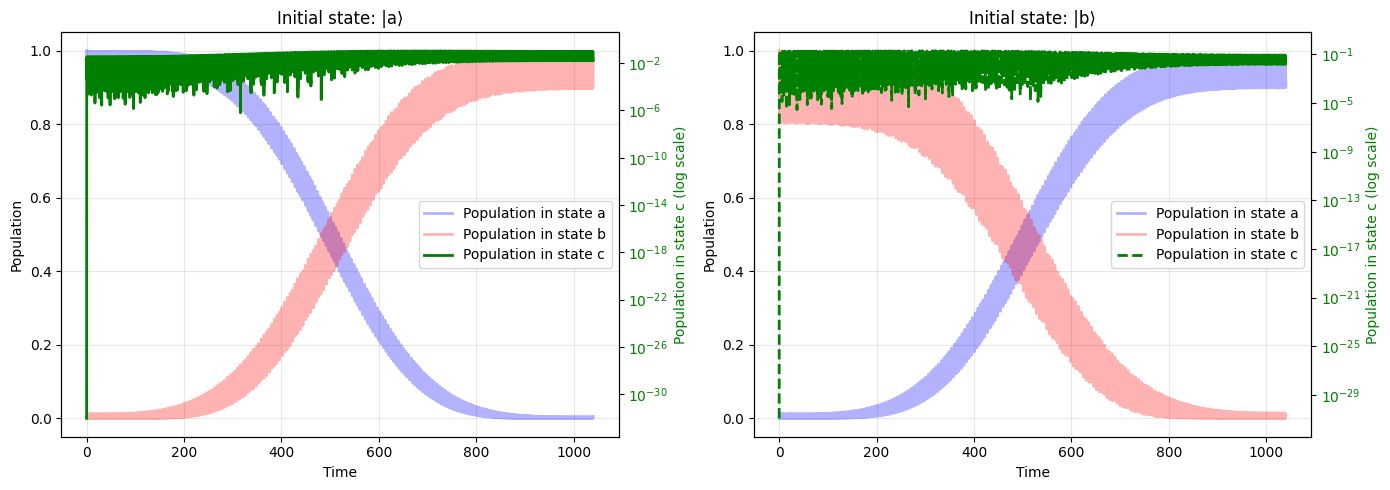

In [13]:
# simulate the result directly over H0 and V1 from s 
lh = [s.H0_dressed, [s.V1_dressed, drive_signal_interp]]
# f_d = extract_fidelity(lh, tlist_fid, sim=s)
fpop_d = extract_pop_fid(lh, tlist_fid, plot=True, plot_c=True, s=s)['iswap_fidelity']
# print(f"infidelity driven: {(1-f_d):.2e} pop: {(1-fpop_d):.2e}")

infidelity gauss drag: 6.58e-01 pop: 8.78e-09
infidelity gauss no drag: 7.11e-01 pop: 1.04e-02


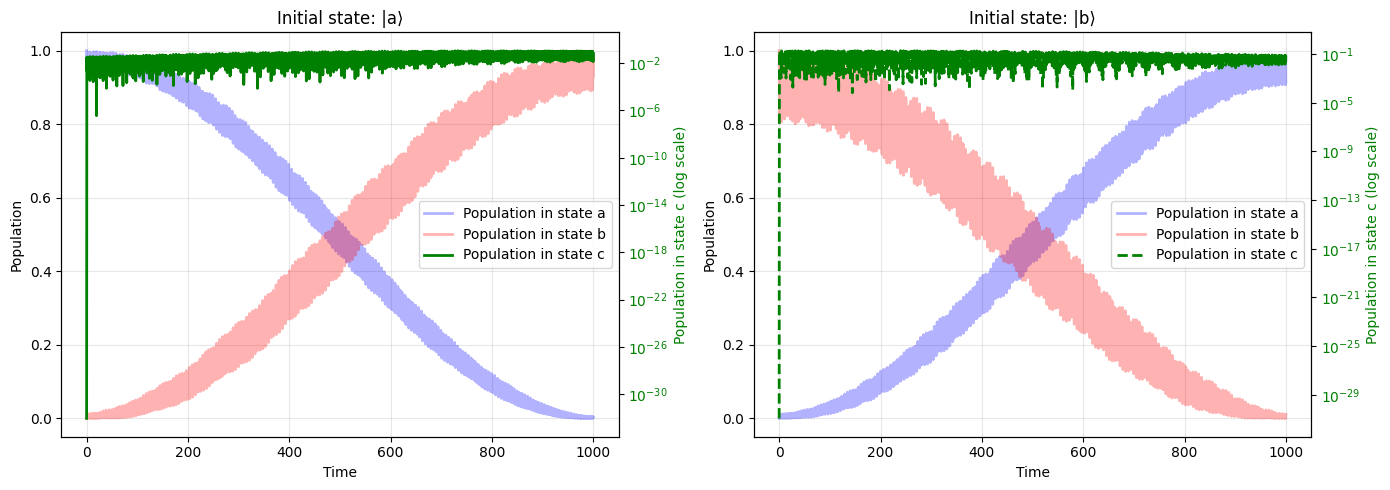

infidelity cos drive direct: 7.14e-01 pop: 1.00e+00


In [14]:
# engineered
tlist_fid = np.linspace(0, tg, 2300)
f_e = extract_fidelity(ht, tlist_fid)
fpop_e = extract_pop_fid(ht, tlist_fid, plot=False)['iswap_fidelity']
print(f"infidelity gauss drag: {(1-f_e):.2e} pop: {(1-fpop_e):.2e}")
# compare to an effective hamiltonian without drag
ht_nodrag, args = compute_htarget(tg, use_drag=False)
f_e_nodrag = extract_fidelity(ht_nodrag, tlist_fid)
fpop_e_nodrag = extract_pop_fid(ht_nodrag, tlist_fid, plot=False)['iswap_fidelity']
print(f"infidelity gauss no drag: {(1-f_e_nodrag):.2e} pop: {(1-fpop_e_nodrag):.2e}")
# verify that drag improves the engineered outcome
h_cos = [s.H0_dressed, [s.V1_dressed, lambda t, args: cos_amp * np.cos(cos_wd * t)]]
f_e_nodrag = extract_fidelity(h_cos, tlist_fid, sim = s)
fpop_e_nodrag = extract_pop_fid(h_cos, tlist_fid, s=s, plot=True, plot_c = True)['iswap_fidelity']
print(f"infidelity cos drive direct: {(1-f_e_nodrag):.2e} pop: {(1-fpop_e_nodrag):.2e}")